# SFT Results

Run all cells to generate paper figures and full results for all dataset/task combinations.

In [41]:
import json
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [42]:
# ============================================
# Configuration
# ============================================
SCRATCH_DIR = "/work/hdd/bfwm/phu1/Project"
out_dir = f"{SCRATCH_DIR}/Gradient-Streaming/SFT"
lr_config_path = "./train/lr/config.json"
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

model = 'Llama-3.2-1B'

# All dataset+task combinations to analyze
DATASETS = [
    {'train': 'alpaca', 'task': 'samsum', 'subject': '', 'percentage': 0.4},
    {'train': 'tulu3',  'task': 'tydiqa', 'subject': '', 'percentage': 0.01},
]

# Shared hyperparameters
SHARED_CONFIG = {
    'batch_size': 8,
    'n_val': 16,
    'lr_full_fallback': '5e-05',
    'lr_lora_fallback': '2e-04',
}

# Methods: "{Method}-{Finetuning}"
ALL_METHODS = [
    'Standard-Full', 'Standard-LoRA', 'Standard-MeSO',
    'Layerwise-Full', 'Layerwise-LoRA', 'Layerwise-MeSO',
    'Subset-Full', 'Subset-LoRA', 'Subset-MeSO',
]

# Paper figure grouping: one plot per finetuning type
FINETUNING_GROUPS = {
    'Full': ['Standard-Full', 'Subset-Full', 'Layerwise-Full'],
    'LoRA': ['Standard-LoRA', 'Subset-LoRA', 'Layerwise-LoRA'],
    'MeSO': ['Standard-MeSO', 'Subset-MeSO', 'Layerwise-MeSO'],
}

LEGEND_NAMES = {
    'Standard-Full': 'Standard', 'Standard-LoRA': 'Standard', 'Standard-MeSO': 'Standard',
    'Layerwise-Full': 'Layer-wise', 'Layerwise-LoRA': 'Layer-wise', 'Layerwise-MeSO': 'Layer-wise',
    'Subset-Full': 'Subset', 'Subset-LoRA': 'Subset', 'Subset-MeSO': 'Subset',
}

METHOD_COLORS = {
    'Standard-Full': 'black', 'Standard-LoRA': 'black', 'Standard-MeSO': 'black',
    'Layerwise-Full': 'red', 'Layerwise-LoRA': 'red', 'Layerwise-MeSO': 'red',
    'Subset-Full': 'green', 'Subset-LoRA': 'green', 'Subset-MeSO': 'green',
}

# Task-specific evaluation metrics
TASK_METRICS = {
    'samsum': {
        'result_file': 'samsum_results.json',
        'metrics': ['rouge1', 'rouge2', 'rougeL'],
        'display_names': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
        'primary_metric': 'rougeL',
        'format': lambda x: f"{x:.3f}" if x is not None else 'N/A',
    },
    'tydiqa': {
        'result_file': 'tydiqa_results.json',
        'metrics': ['f1_score', 'exact_match'],
        'display_names': ['F1 Score', 'Exact Match'],
        'primary_metric': 'f1_score',
        'format': lambda x: f"{x:.2f}" if x is not None else 'N/A',
    },
}

# Val-ablation: train on ~n_val validation samples (Standard methods only)
VAL_ABLATION = [
    {'task': 'tydiqa', 'max_steps': 9392, 'train': 'tulu3', 'main_ds_key': 'tulu3_tydiqa'},
    {'task': 'samsum', 'max_steps': 20800, 'train': 'alpaca', 'main_ds_key': 'alpaca_samsum'},
]
VAL_ABLATION_METHODS = ['Standard-Full', 'Standard-LoRA', 'Standard-MeSO']
VAL_ABLATION_CONFIG = {'batch_size': 1, 'n_val': 16}

# Load LR configuration
lr_config = {}
if Path(lr_config_path).exists():
    with open(lr_config_path, 'r') as f:
        lr_config = json.load(f)
    print(f"Loaded LR config from {lr_config_path}")

print(f"Datasets: {[(d['train'], d['task']) for d in DATASETS]}")
print(f"Methods: {len(ALL_METHODS)}")
print(f"Val-ablation tasks: {[va['task'] for va in VAL_ABLATION]}")

Loaded LR config from ./train/lr/config.json
Datasets: [('alpaca', 'samsum'), ('tulu3', 'tydiqa')]
Methods: 9
Val-ablation tasks: ['tydiqa', 'samsum']


## Helper Functions & Load All Data

In [43]:
# ============================================
# Helper functions (parameterized, no globals)
# ============================================

def _finetuning_type(name):
    return name.split('-', 1)[1]

def _config_key(train_dataset, task, subject=''):
    if task in ['mmlu', 'bbh'] and subject:
        return f"{train_dataset}_{task}_{subject}"
    return f"{train_dataset}_{task}"

def _lookup_lr(method_name, train_dataset, task, subject=''):
    key = _config_key(train_dataset, task, subject)
    if lr_config and key in lr_config:
        entry = lr_config[key].get(method_name, {})
        lr_val = entry.get('lr')
        if lr_val is not None:
            return f'{lr_val:.0e}' if lr_val < 0.001 else f'{lr_val}'
    ft = _finetuning_type(method_name)
    return SHARED_CONFIG['lr_lora_fallback'] if ft == 'LoRA' else SHARED_CONFIG['lr_full_fallback']

def _dir_name(method_name, seed, ds):
    """Build experiment directory name."""
    lr = _lookup_lr(method_name, ds['train'], ds['task'], ds.get('subject', ''))
    task_str = f"{ds['task']}_{ds['subject']}" if ds['task'] in ['mmlu', 'bbh'] and ds.get('subject') else ds['task']
    cfg = SHARED_CONFIG
    return (f"{ds['train']}_{task_str}-{model}-{method_name}"
            f"-p{ds['percentage']}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{seed}")

def _discover_seeds(method_name, ds):
    pattern = _dir_name(method_name, '*', ds)
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def _load_eval_results(path):
    with open(path, 'r') as f:
        data = json.load(f)
    steps = [item['step'] for item in data]
    val_ppl = [item['val_perplexity'] for item in data]
    eval_ppl = [item['eval_perplexity'] for item in data]
    wt = [item.get('wall_time') for item in data]
    # Use train_wall_time (eval time subtracted) if available, fall back to wall_time
    twt = [item.get('train_wall_time', item.get('wall_time')) for item in data]
    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_ppl),
        'eval_perplexity': np.array(eval_ppl),
        'wall_time': np.array(wt) if all(t is not None for t in wt) else None,
        'train_wall_time': np.array(twt) if all(t is not None for t in twt) else None,
    }

def load_method_results(method_name, ds):
    """Load and aggregate results across all seeds for a method + dataset."""
    seeds = _discover_seeds(method_name, ds)
    if not seeds:
        return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_dir_name(method_name, seed, ds)}/evaluation_results.json"
        if Path(path).exists():
            all_res.append(_load_eval_results(path))
            valid_seeds.append(seed)
    if not all_res:
        return None
    min_len = min(len(r['steps']) for r in all_res)
    steps = all_res[0]['steps'][:min_len]
    val_ppl = np.stack([r['val_perplexity'][:min_len] for r in all_res])
    eval_ppl = np.stack([r['eval_perplexity'][:min_len] for r in all_res])
    wts = [r['wall_time'] for r in all_res if r['wall_time'] is not None]
    if len(wts) == len(all_res):
        wt = np.stack([w[:min_len] for w in wts])
        wt_mean, wt_std = np.mean(wt, axis=0), np.std(wt, axis=0)
    else:
        wt_mean = wt_std = None
    # train_wall_time: eval time subtracted
    twts = [r['train_wall_time'] for r in all_res if r['train_wall_time'] is not None]
    if len(twts) == len(all_res):
        twt = np.stack([w[:min_len] for w in twts])
        twt_mean, twt_std = np.mean(twt, axis=0), np.std(twt, axis=0)
    else:
        twt_mean = twt_std = None
    return {
        'steps': steps,
        'val_perplexity_mean': np.mean(val_ppl, axis=0), 'val_perplexity_std': np.std(val_ppl, axis=0),
        'eval_perplexity_mean': np.mean(eval_ppl, axis=0), 'eval_perplexity_std': np.std(eval_ppl, axis=0),
        'wall_time_mean': wt_mean, 'wall_time_std': wt_std,
        'train_wall_time_mean': twt_mean, 'train_wall_time_std': twt_std,
        'n_seeds': len(valid_seeds), 'seeds': valid_seeds,
    }

def load_task_metric(method_name, ds, seeds):
    """Load task-specific eval (ROUGE, F1, etc.) across seeds."""
    task = ds['task']
    if task not in TASK_METRICS:
        return None
    result_file = TASK_METRICS[task]['result_file']
    seed_results, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_dir_name(method_name, seed, ds)}/{result_file}"
        if Path(path).exists():
            with open(path, 'r') as f:
                seed_results.append(json.load(f))
                valid_seeds.append(seed)
    if not seed_results:
        return None
    aggregated = {'seeds': valid_seeds, 'n_seeds': len(valid_seeds)}
    for metric in TASK_METRICS[task]['metrics']:
        values = [r.get(metric) for r in seed_results if r.get(metric) is not None]
        if values:
            aggregated[f'{metric}_mean'] = np.mean(values)
            aggregated[f'{metric}_std'] = np.std(values)
        else:
            aggregated[f'{metric}_mean'] = None
            aggregated[f'{metric}_std'] = None
    return aggregated


# ============================================
# Load ALL data upfront
# ============================================
# all_results[ds_key][method_name] = {steps, eval_perplexity_mean, ...}
# all_task_results[ds_key][method_name] = {rougeL_mean, f1_score_mean, ...}

all_results = {}
all_task_results = {}

for ds in DATASETS:
    ds_key = f"{ds['train']}_{ds['task']}"
    print(f"\n{'='*60}")
    print(f"Loading: {ds_key}")
    print(f"{'='*60}")

    results = {}
    task_results = {}

    for method_name in ALL_METHODS:
        data = load_method_results(method_name, ds)
        if data:
            results[method_name] = data
            seeds = data['seeds']
            print(f"  + {method_name}: {data['n_seeds']} seeds, {len(data['steps'])} points")

            # Also load task-specific metrics
            tdata = load_task_metric(method_name, ds, seeds)
            if tdata:
                task_results[method_name] = tdata
        else:
            print(f"  - {method_name}: Not found")

    all_results[ds_key] = results
    all_task_results[ds_key] = task_results
    print(f"  Loaded {len(results)}/{len(ALL_METHODS)} training, {len(task_results)} task-specific")

print(f"\n{'='*60}")
print(f"All data loaded: {list(all_results.keys())}")
print(f"{'='*60}")


Loading: alpaca_samsum
  + Standard-Full: 2 seeds, 55 points
  + Standard-LoRA: 2 seeds, 55 points
  + Standard-MeSO: 1 seeds, 55 points
  + Layerwise-Full: 1 seeds, 55 points
  + Layerwise-LoRA: 1 seeds, 55 points
  + Layerwise-MeSO: 1 seeds, 55 points
  + Subset-Full: 1 seeds, 55 points
  + Subset-LoRA: 1 seeds, 55 points
  + Subset-MeSO: 1 seeds, 53 points
  Loaded 9/9 training, 0 task-specific

Loading: tulu3_tydiqa
  + Standard-Full: 2 seeds, 25 points
  + Standard-LoRA: 1 seeds, 25 points
  + Standard-MeSO: 1 seeds, 25 points
  + Layerwise-Full: 1 seeds, 25 points
  + Layerwise-LoRA: 1 seeds, 25 points
  + Layerwise-MeSO: 1 seeds, 25 points
  + Subset-Full: 1 seeds, 25 points
  + Subset-LoRA: 1 seeds, 25 points
  + Subset-MeSO: 1 seeds, 25 points
  Loaded 9/9 training, 0 task-specific

All data loaded: ['alpaca_samsum', 'tulu3_tydiqa']


In [44]:
# ============================================
# Val-ablation: load training curves + task metrics
# ============================================

def _val_ablation_dir_name(method_name, seed, va):
    """Build val-ablation experiment directory name."""
    lr = _lookup_lr(method_name, va['train'], va['task'])
    cfg = VAL_ABLATION_CONFIG
    task = va['task']
    return (f"{task}_val_{task}-{model}-{method_name}"
            f"-ms{va['max_steps']}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{seed}")

def _discover_val_ablation_seeds(method_name, va):
    pattern = _val_ablation_dir_name(method_name, '*', va)
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def load_val_ablation_results(method_name, va):
    """Load and aggregate val-ablation results across seeds."""
    seeds = _discover_val_ablation_seeds(method_name, va)
    if not seeds:
        return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_val_ablation_dir_name(method_name, seed, va)}/evaluation_results.json"
        if Path(path).exists():
            all_res.append(_load_eval_results(path))
            valid_seeds.append(seed)
    if not all_res:
        return None
    min_len = min(len(r['steps']) for r in all_res)
    steps = all_res[0]['steps'][:min_len]
    val_ppl = np.stack([r['val_perplexity'][:min_len] for r in all_res])
    eval_ppl = np.stack([r['eval_perplexity'][:min_len] for r in all_res])
    wts = [r['wall_time'] for r in all_res if r['wall_time'] is not None]
    wt_mean = wt_std = None
    if len(wts) == len(all_res):
        wt = np.stack([w[:min_len] for w in wts])
        wt_mean, wt_std = np.mean(wt, axis=0), np.std(wt, axis=0)
    twts = [r['train_wall_time'] for r in all_res if r['train_wall_time'] is not None]
    twt_mean = twt_std = None
    if len(twts) == len(all_res):
        twt = np.stack([w[:min_len] for w in twts])
        twt_mean, twt_std = np.mean(twt, axis=0), np.std(twt, axis=0)
    return {
        'steps': steps,
        'val_perplexity_mean': np.mean(val_ppl, axis=0), 'val_perplexity_std': np.std(val_ppl, axis=0),
        'eval_perplexity_mean': np.mean(eval_ppl, axis=0), 'eval_perplexity_std': np.std(eval_ppl, axis=0),
        'wall_time_mean': wt_mean, 'wall_time_std': wt_std,
        'train_wall_time_mean': twt_mean, 'train_wall_time_std': twt_std,
        'n_seeds': len(valid_seeds), 'seeds': valid_seeds,
    }

def load_val_ablation_task_metric(method_name, va, seeds):
    """Load task-specific eval (ROUGE, F1) for val-ablation experiments."""
    task = va['task']
    if task not in TASK_METRICS:
        return None
    result_file = TASK_METRICS[task]['result_file']
    seed_results, valid_seeds = [], []
    for seed in seeds:
        path = f"{out_dir}/{_val_ablation_dir_name(method_name, seed, va)}/{result_file}"
        if Path(path).exists():
            with open(path, 'r') as f:
                seed_results.append(json.load(f))
                valid_seeds.append(seed)
    if not seed_results:
        return None
    aggregated = {'seeds': valid_seeds, 'n_seeds': len(valid_seeds)}
    for metric in TASK_METRICS[task]['metrics']:
        values = [r.get(metric) for r in seed_results if r.get(metric) is not None]
        if values:
            aggregated[f'{metric}_mean'] = np.mean(values)
            aggregated[f'{metric}_std'] = np.std(values)
        else:
            aggregated[f'{metric}_mean'] = None
            aggregated[f'{metric}_std'] = None
    return aggregated

# Load val-ablation data keyed by main dataset key
# val_ablation_results[main_ds_key][method_name] = {steps, perplexity, wall_time, ...}
# val_ablation_task_results[main_ds_key][method_name] = {f1_score_mean, rougeL_mean, ...}
val_ablation_results = {}
val_ablation_task_results = {}

for va in VAL_ABLATION:
    ds_key = va['main_ds_key']
    print(f"\n{'='*60}")
    print(f"Loading val-ablation for {ds_key}")
    print(f"{'='*60}")
    results = {}
    task_results = {}
    for method_name in VAL_ABLATION_METHODS:
        data = load_val_ablation_results(method_name, va)
        if data:
            results[method_name] = data
            seeds = data['seeds']
            print(f"  + {method_name}: {data['n_seeds']} seeds, {len(data['steps'])} points")
            tdata = load_val_ablation_task_metric(method_name, va, seeds)
            if tdata:
                task_results[method_name] = tdata
                print(f"    task metrics: {list(k for k in tdata if '_mean' in k)}")
        else:
            print(f"  - {method_name}: Not found")
    val_ablation_results[ds_key] = results
    val_ablation_task_results[ds_key] = task_results
    print(f"  Loaded {len(results)}/{len(VAL_ABLATION_METHODS)} training, {len(task_results)} task-specific")


Loading val-ablation for tulu3_tydiqa
  + Standard-Full: 5 seeds, 48 points
    task metrics: ['f1_score_mean', 'exact_match_mean']
  + Standard-LoRA: 5 seeds, 48 points
    task metrics: ['f1_score_mean', 'exact_match_mean']
  + Standard-MeSO: 5 seeds, 48 points
    task metrics: ['f1_score_mean', 'exact_match_mean']
  Loaded 3/3 training, 3 task-specific

Loading val-ablation for alpaca_samsum
  + Standard-Full: 5 seeds, 106 points
    task metrics: ['rouge1_mean', 'rouge2_mean', 'rougeL_mean']
  + Standard-LoRA: 5 seeds, 106 points
    task metrics: ['rouge1_mean', 'rouge2_mean', 'rougeL_mean']
  + Standard-MeSO: 5 seeds, 106 points
    task metrics: ['rouge1_mean', 'rouge2_mean', 'rougeL_mean']
  Loaded 3/3 training, 3 task-specific


## Paper Figures: Eval Perplexity vs Wall Time

One plot per (dataset, finetuning type). Each plot compares Standard vs Subset vs Layer-wise.


  alpaca_samsum

  [alpaca_samsum] Full: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-Full: 2 seeds, final=5.8585
    + Subset-Full: 1 seeds, final=5.4814
    + Layerwise-Full: 1 seeds, final=5.2195
    -> Saved: ./figures/alpaca_samsum_Full.pdf


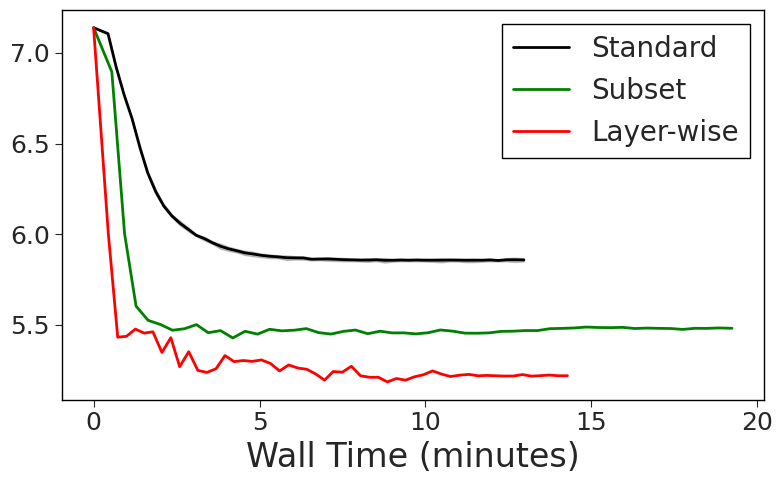


  [alpaca_samsum] LoRA: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-LoRA: 2 seeds, final=5.6758
    + Subset-LoRA: 1 seeds, final=5.5286
    + Layerwise-LoRA: 1 seeds, final=5.0299
    -> Saved: ./figures/alpaca_samsum_LoRA.pdf


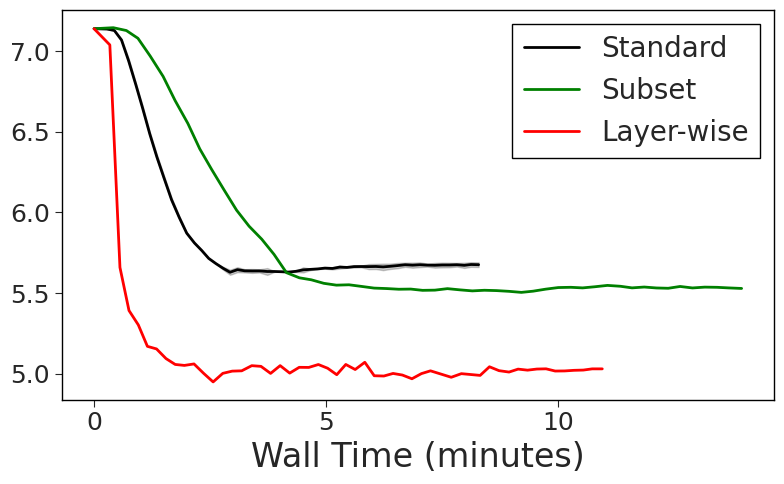


  [alpaca_samsum] MeSO: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-MeSO: 1 seeds, final=6.1130
    + Subset-MeSO: 1 seeds, final=5.5318
    + Layerwise-MeSO: 1 seeds, final=5.0247
    -> Saved: ./figures/alpaca_samsum_MeSO.pdf


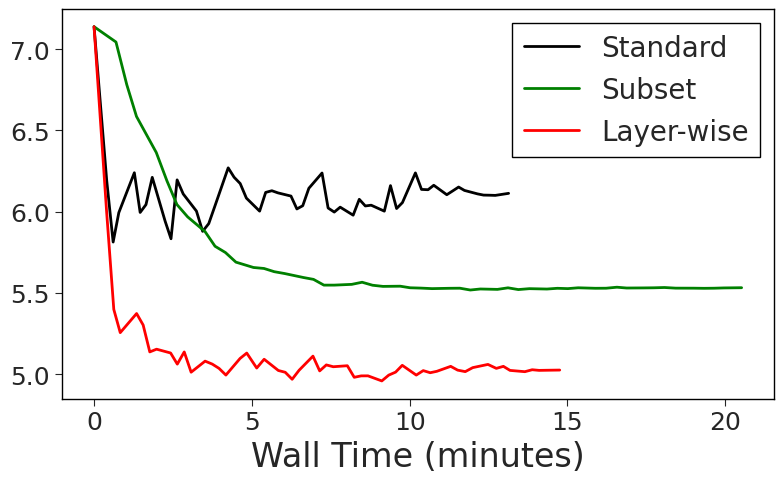


  tulu3_tydiqa

  [tulu3_tydiqa] Full: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-Full: 2 seeds, final=2.0414
    + Subset-Full: 1 seeds, final=1.7069
    + Layerwise-Full: 1 seeds, final=1.5737
    -> Saved: ./figures/tulu3_tydiqa_Full.pdf


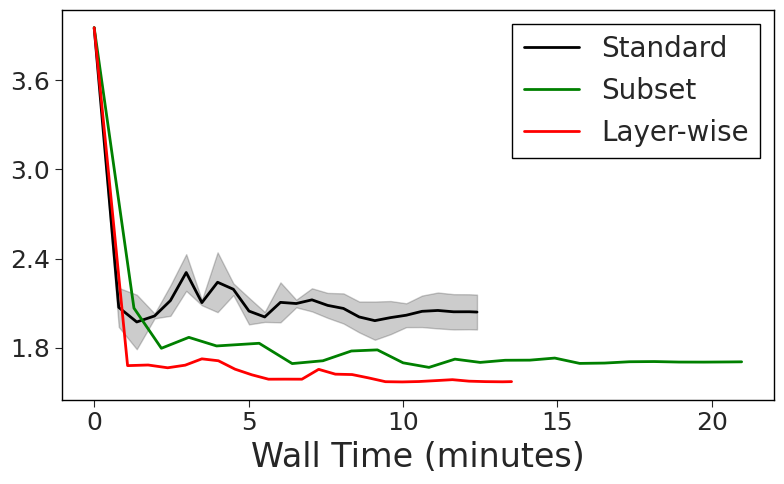


  [tulu3_tydiqa] LoRA: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-LoRA: 1 seeds, final=2.1080
    + Subset-LoRA: 1 seeds, final=1.7274
    + Layerwise-LoRA: 1 seeds, final=1.5386
    -> Saved: ./figures/tulu3_tydiqa_LoRA.pdf


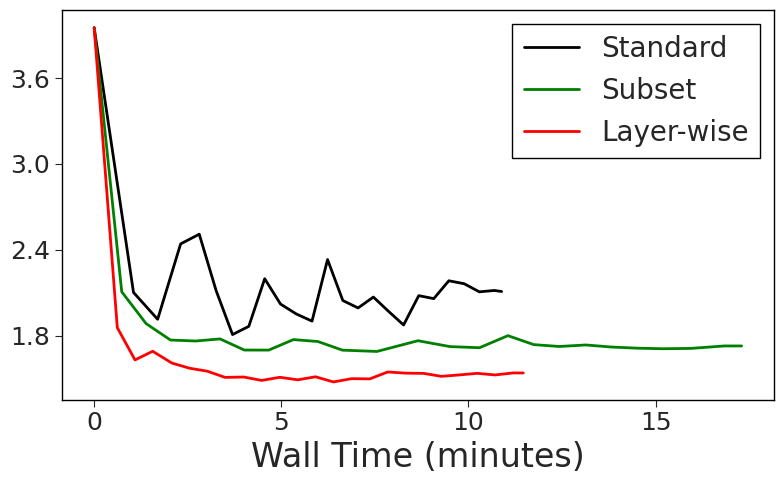


  [tulu3_tydiqa] MeSO: Eval Perplexity vs Wall Time
    Methods: Standard, Subset, Layer-wise
    + Standard-MeSO: 1 seeds, final=2.1156
    + Subset-MeSO: 1 seeds, final=1.6985
    + Layerwise-MeSO: 1 seeds, final=1.6836
    -> Saved: ./figures/tulu3_tydiqa_MeSO.pdf


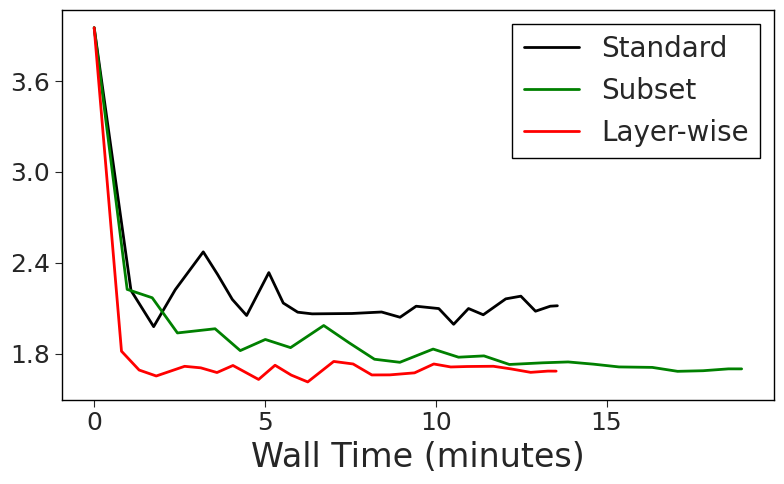

In [45]:
# Paper figures: one per (dataset, finetuning type)
# Each compares Standard vs Subset vs Layerwise on eval perplexity vs wall time
# Uses train_wall_time (eval time subtracted) when available, falls back to wall_time

time_cutoff_minutes = None  # Set to clip x-axis

for ds in DATASETS:
    ds_key = f"{ds['train']}_{ds['task']}"
    results = all_results[ds_key]

    print(f"\n{'='*60}")
    print(f"  {ds_key}")
    print(f"{'='*60}")

    for ft_name, ft_methods in FINETUNING_GROUPS.items():
        print(f"\n  [{ds_key}] {ft_name}: Eval Perplexity vs Wall Time")
        print(f"    Methods: {', '.join(LEGEND_NAMES.get(m, m) for m in ft_methods)}")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')

        has_data = False
        for method_name in ft_methods:
            if method_name not in results:
                print(f"    - {method_name}: no data")
                continue
            data = results[method_name]
            # Prefer train_wall_time (eval time subtracted), fall back to wall_time
            wt = data['train_wall_time_mean'] if data['train_wall_time_mean'] is not None else data['wall_time_mean']
            if wt is None:
                print(f"    - {method_name}: no wall time")
                continue

            x = wt / 60.0
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            color = METHOD_COLORS.get(method_name)
            display = LEGEND_NAMES.get(method_name, method_name)

            ax.plot(x, mean, linewidth=2, label=display, color=color)
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
            has_data = True
            print(f"    + {method_name}: {data['n_seeds']} seeds, final={mean[-1]:.4f}")

        ax.set_xlabel('Wall Time (minutes)', fontsize=24)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=18, direction='out', length=5)
        ax.xaxis.set_major_locator(MultipleLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        if time_cutoff_minutes is not None:
            ax.set_xlim(left=0, right=time_cutoff_minutes)

        if has_data:
            legend = ax.legend(loc='upper right', fontsize=20, frameon=True,
                              edgecolor='black', fancybox=False, framealpha=1.0)
            legend.get_frame().set_facecolor('white')
        else:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=15, color='gray')

        plt.tight_layout()
        filepath = os.path.join(save_dir, f"{ds_key}_{ft_name}.pdf")
        fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"    -> Saved: {filepath}")
        plt.show()

## Results Tables: Task-Specific Metrics (All Datasets)

In [46]:
def _fmt(mean, std, n_seeds, fmt_fn=None):
    if mean is None:
        return 'N/A'
    if fmt_fn:
        base = fmt_fn(mean)
    else:
        base = f"{mean:.4f}"
    if n_seeds > 1 and std is not None:
        if '%' in base:
            return f"{mean*100:.1f} +/- {std*100:.1f}%"
        return f"{mean:.4f} +/- {std:.4f}" if fmt_fn is None else f"{mean:.3f} +/- {std:.3f}"
    return base


for ds in DATASETS:
    ds_key = f"{ds['train']}_{ds['task']}"
    task_results = all_task_results[ds_key]
    task = ds['task']

    if task_results and task in TASK_METRICS:
        tm = TASK_METRICS[task]
        primary = tm['primary_metric']

        print(f"\n{'='*100}")
        print(f"  {ds_key} ({task.upper()})")
        print(f"{'='*100}")
        header = f"{'Method':<25} {'Seeds':<7}"
        for dn in tm['display_names']:
            header += f" {dn:>18}"
        print(header)
        print("-" * 100)

        for name, data in sorted(task_results.items(),
                                  key=lambda x: x[1].get(f'{primary}_mean', 0) or 0, reverse=True):
            n = data['n_seeds']
            row = f"{name:<25} {n:<7}"
            for metric in tm['metrics']:
                mean = data.get(f'{metric}_mean')
                std = data.get(f'{metric}_std')
                row += f" {_fmt(mean, std, n, tm['format']):>18}"
            print(row)
        print(f"{'='*100}")
        print(f"Loaded {len(task_results)}/{len(ALL_METHODS)} results")
    else:
        print(f"\nNo task-specific results for {ds_key}. Run: bash submit.sh SFT/eval/eval.sh --train {ds['train']} --task {task} --batch_size 32")


No task-specific results for alpaca_samsum. Run: bash submit.sh SFT/eval/eval.sh --train alpaca --task samsum --batch_size 32

No task-specific results for tulu3_tydiqa. Run: bash submit.sh SFT/eval/eval.sh --train tulu3 --task tydiqa --batch_size 32


## Global Comparison: All Methods + Val-Ablation

Combined 3x2 grid (Full/LoRA/MeSO x SAMSUM/TYDIQA) with val-ablation baselines (dashed blue). Global table includes all methods + val-ablation results.

Saved: ./figures/sft_global_comparison.pdf


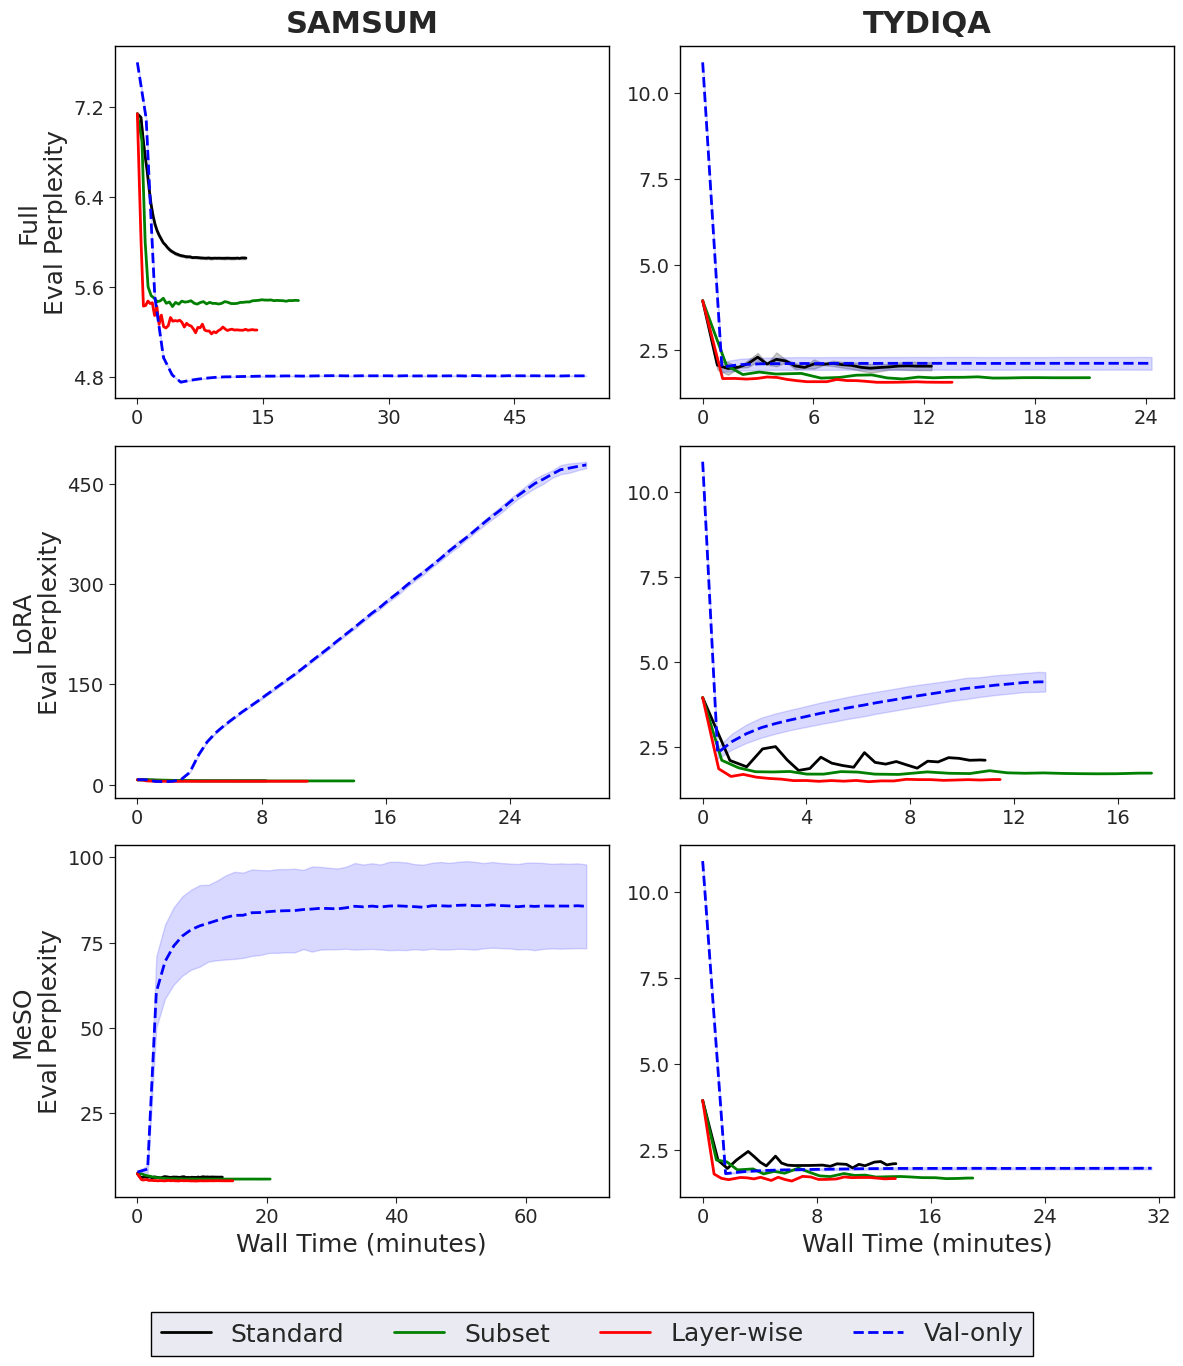

In [47]:
# ============================================
# Global Comparison Grid: All Methods + Val-Ablation
# ============================================
# 3 rows (Full, LoRA, MeSO) x 2 columns (SAMSUM, TYDIQA)
# Solid: Standard (black), Layer-wise (red), Subset (green)
# Dashed: Val-only (blue)

DATASET_TITLES = {'alpaca_samsum': 'SAMSUM', 'tulu3_tydiqa': 'TYDIQA'}
FT_ORDER = ['Full', 'LoRA', 'MeSO']

time_cutoff_minutes_global = None

ncols = len(DATASETS)
nrows = len(FT_ORDER)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
fig.patch.set_facecolor('white')

for col_idx, ds in enumerate(DATASETS):
    ds_key = f"{ds['train']}_{ds['task']}"
    results = all_results[ds_key]
    va_results = val_ablation_results.get(ds_key, {})

    for row_idx, ft_name in enumerate(FT_ORDER):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor('white')
        ft_methods = FINETUNING_GROUPS[ft_name]

        # Main methods (solid lines)
        for method_name in ft_methods:
            if method_name not in results:
                continue
            data = results[method_name]
            wt = data['train_wall_time_mean'] if data['train_wall_time_mean'] is not None else data['wall_time_mean']
            if wt is None:
                continue
            x = wt / 60.0
            mean = data['eval_perplexity_mean']
            std = data['eval_perplexity_std']
            color = METHOD_COLORS[method_name]
            label = LEGEND_NAMES[method_name]
            ax.plot(x, mean, linewidth=2, label=label, color=color)
            if data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        # Val-ablation (dashed blue line)
        va_method = f"Standard-{ft_name}"
        if va_method in va_results:
            data = va_results[va_method]
            wt = data['train_wall_time_mean'] if data['train_wall_time_mean'] is not None else data['wall_time_mean']
            if wt is not None:
                x = wt / 60.0
                mean = data['eval_perplexity_mean']
                std = data['eval_perplexity_std']
                ax.plot(x, mean, linewidth=2, label='Val-only', color='blue', linestyle='--')
                if data['n_seeds'] > 1:
                    ax.fill_between(x, mean - std, mean + std, color='blue', alpha=0.15)

        # Formatting
        if row_idx == 0:
            ax.set_title(DATASET_TITLES.get(ds_key, ds_key), fontsize=22, fontweight='bold', pad=10)
        if row_idx == nrows - 1:
            ax.set_xlabel('Wall Time (minutes)', fontsize=18)
        if col_idx == 0:
            ax.set_ylabel(f'{ft_name}\nEval Perplexity', fontsize=18)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=14, direction='out', length=4)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        if time_cutoff_minutes_global is not None:
            ax.set_xlim(left=0, right=time_cutoff_minutes_global)

# Shared legend at bottom (deduplicated)
handles, labels = [], []
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
seen = {}
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=len(unique_labels),
           fontsize=18, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
filepath = os.path.join(save_dir, 'sft_global_comparison.pdf')
fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"Saved: {filepath}")
plt.show()

In [48]:
# ============================================
# Global Table: All Methods + Val-Ablation
# ============================================

VA_DISPLAY = {
    'Standard-Full': 'Val-only (Full)',
    'Standard-LoRA': 'Val-only (LoRA)',
    'Standard-MeSO': 'Val-only (MeSO)',
}

for ds in DATASETS:
    ds_key = f"{ds['train']}_{ds['task']}"
    task = ds['task']
    main_task = all_task_results.get(ds_key, {})
    va_task = val_ablation_task_results.get(ds_key, {})

    if task not in TASK_METRICS:
        continue
    tm = TASK_METRICS[task]
    primary = tm['primary_metric']

    print(f"\n{'='*100}")
    print(f"  {ds_key} ({task.upper()}) -- All Methods + Val-Ablation")
    print(f"{'='*100}")
    header = f"{'Method':<25} {'Seeds':<7}"
    for dn in tm['display_names']:
        header += f" {dn:>18}"
    print(header)
    print("-" * 100)

    # Main methods sorted by primary metric
    for name, data in sorted(main_task.items(),
                              key=lambda x: x[1].get(f'{primary}_mean', 0) or 0, reverse=True):
        n = data['n_seeds']
        row = f"{name:<25} {n:<7}"
        for metric in tm['metrics']:
            mean = data.get(f'{metric}_mean')
            std = data.get(f'{metric}_std')
            row += f" {_fmt(mean, std, n, tm['format']):>18}"
        print(row)

    # Val-ablation separator + entries
    if va_task:
        print(f"{'- val-ablation ':-<100}")
        for name, data in sorted(va_task.items(),
                                  key=lambda x: x[1].get(f'{primary}_mean', 0) or 0, reverse=True):
            display = VA_DISPLAY.get(name, name)
            n = data['n_seeds']
            row = f"{display:<25} {n:<7}"
            for metric in tm['metrics']:
                mean = data.get(f'{metric}_mean')
                std = data.get(f'{metric}_std')
                row += f" {_fmt(mean, std, n, tm['format']):>18}"
            print(row)

    print(f"{'='*100}")


  alpaca_samsum (SAMSUM) -- All Methods + Val-Ablation
Method                    Seeds              ROUGE-1            ROUGE-2            ROUGE-L
----------------------------------------------------------------------------------------------------
- val-ablation -------------------------------------------------------------------------------------
Val-only (LoRA)           5          0.388 +/- 0.003    0.132 +/- 0.003    0.299 +/- 0.002
Val-only (MeSO)           5          0.368 +/- 0.011    0.121 +/- 0.007    0.284 +/- 0.009
Val-only (Full)           5          0.307 +/- 0.003    0.091 +/- 0.002    0.233 +/- 0.002

  tulu3_tydiqa (TYDIQA) -- All Methods + Val-Ablation
Method                    Seeds             F1 Score        Exact Match
----------------------------------------------------------------------------------------------------
- val-ablation -------------------------------------------------------------------------------------
Val-only (Full)           5         59.024 +/- 1.